# Beijing's Air Quality After the 2013 Clean Air Action Plan
**Part 3 — Meteorological Confound and Spatial Variation**

Parts 1 and 2 established two things. Part 1 showed that PM2.5 varies far more *within* a year (seasonal and diurnal cycles) than *between* years, so raw annual means are fragile. Part 2 then estimated the trend and found that SO₂ fell most clearly over 2014–2016, while PM2.5 declined more modestly (about −17% in the citywide annual mean).

**This notebook asks the question Part 2 could not answer: is the PM2.5 decline real, or did the weather just cooperate?** Wind disperses particulate pollution, so a year that happens to be windier will look cleaner even if emissions are unchanged. Part 3 does two things:

1. **Quantifies the meteorological confound** — how strongly wind *speed* and wind *direction* control PM2.5.
2. **Tests whether the 2014→2016 decline survives** once we hold the weather fixed, by recomputing the change on stagnant (low-wind) days only, and shows how PM2.5 varies **spatially** across urban and background stations.

**Hypothesis (recap):** coal-linked SO₂ fell sharply and steadily, while PM2.5 improved more modestly and was partly hidden — and, as we will see, *partly helped* — by year-to-year swings in the weather.

**Data:** hourly observations from twelve stations, March 2013–February 2017, six pollutants plus co-located meteorology (wind direction `wd`, wind speed `WSPM` in m/s), loaded directly from the UCI Machine Learning Repository. Only 2014, 2015, and 2016 are complete calendar years, so all year-to-year comparisons use those three.

In [1]:
import warnings
warnings.filterwarnings("ignore", message=".*OpenSSL.*")  # cosmetic macOS/LibreSSL import notice

import io, zipfile, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Load the dataset directly from UCI (same source as Parts 1 and 2)
url = "https://archive.ics.uci.edu/static/public/501/beijing+multi+site+air+quality+data.zip"
r = requests.get(url, timeout=120)
r.raise_for_status()
outer = zipfile.ZipFile(io.BytesIO(r.content))
inner_name = [n for n in outer.namelist() if n.lower().endswith(".zip")][0]
inner = zipfile.ZipFile(io.BytesIO(outer.read(inner_name)))
frames = [pd.read_csv(inner.open(n)) for n in inner.namelist() if n.lower().endswith(".csv")]
df = pd.concat(frames, ignore_index=True)

# Build a datetime index
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df = df.set_index("datetime").sort_index()

print("coverage:", df.index.min(), "->", df.index.max())
print("stations:", df["station"].nunique())
print("wind fields — WSPM (m/s) range:", df["WSPM"].min(), "to", df["WSPM"].max(),
      "| wd categories:", df["wd"].nunique())
print("missing fraction (PM2.5 %.3f, WSPM %.4f, wd %.4f)"
      % (df["PM2.5"].isna().mean(), df["WSPM"].isna().mean(), df["wd"].isna().mean()))

coverage: 2013-03-01 00:00:00 -> 2017-02-28 23:00:00
stations: 12
wind fields — WSPM (m/s) range: 0.0 to 13.2 | wd categories: 16
missing fraction (PM2.5 0.021, WSPM 0.0008, wd 0.0043)


## 1. Wind speed controls PM2.5

Before we can trust any trend, we need to see how strongly weather moves PM2.5 in the first place. Wind speed is the most direct dispersion lever: stronger wind ventilates the boundary layer and dilutes particulate matter. Here we bin every hourly observation by its wind speed (`WSPM`) and take the mean PM2.5 in each bin, with a shaded band showing the interquartile spread.

mean PM2.5 on calm hours (<0.5 m/s): 105 µg/m³
mean PM2.5 on windy hours (>4 m/s): 28 µg/m³
Pearson correlation PM2.5 vs wind speed: -0.27


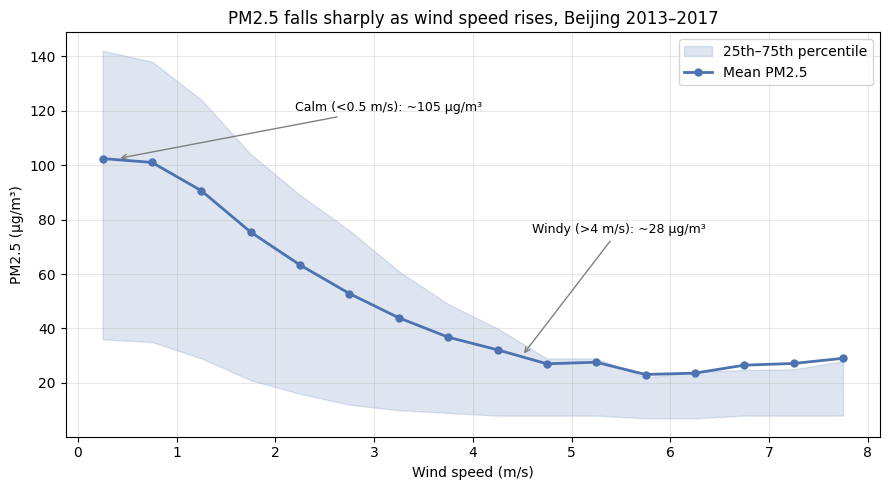

In [2]:
d = df.dropna(subset=["PM2.5", "WSPM"])
bins = np.arange(0, 8.01, 0.5)
d = d.assign(wsbin=pd.cut(d["WSPM"], bins))
g = d.groupby("wsbin", observed=True)["PM2.5"].agg(
    mean="mean",
    p25=lambda s: s.quantile(0.25),
    p75=lambda s: s.quantile(0.75),
    n="count",
)
centers = np.array([iv.mid for iv in g.index])

calm = d.loc[d["WSPM"] < 0.5, "PM2.5"].mean()
windy = d.loc[d["WSPM"] > 4, "PM2.5"].mean()
corr = df[["PM2.5", "WSPM"]].corr().iloc[0, 1]
print(f"mean PM2.5 on calm hours (<0.5 m/s): {calm:.0f} µg/m³")
print(f"mean PM2.5 on windy hours (>4 m/s): {windy:.0f} µg/m³")
print(f"Pearson correlation PM2.5 vs wind speed: {corr:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(centers, g["p25"], g["p75"], color="#4c72b0", alpha=0.18,
                label="25th–75th percentile")
ax.plot(centers, g["mean"], color="#4c72b0", marker="o", ms=5, lw=2, label="Mean PM2.5")
ax.set_xlabel("Wind speed (m/s)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("PM2.5 falls sharply as wind speed rises, Beijing 2013–2017")
ax.grid(alpha=0.3)
ax.legend()
ax.annotate(f"Calm (<0.5 m/s): ~{calm:.0f} µg/m³", xy=(0.4, g["mean"].iloc[0]),
            xytext=(2.2, 120), arrowprops=dict(arrowstyle="->", color="gray"), fontsize=9)
ax.annotate(f"Windy (>4 m/s): ~{windy:.0f} µg/m³", xy=(4.5, 30),
            xytext=(4.6, 75), arrowprops=dict(arrowstyle="->", color="gray"), fontsize=9)
plt.tight_layout()
plt.show()

Mean PM2.5 collapses from about **105 µg/m³ on near-calm hours to under 30 µg/m³ once wind exceeds 4 m/s** — a factor of roughly 3.5. The interquartile band shrinks with it: calm hours span everything from clean to severe haze, while windy hours are reliably clean. The overall Pearson correlation (−0.27) understates this because the relationship is steeply curved rather than linear.

The practical consequence for the trend question is immediate: **if two years differ in how often the air is calm, they will differ in PM2.5 even with identical emissions.** That is the confound Section 4 must neutralize.

## 2. Where the dirty air comes from — the pollution rose

Wind *direction* matters as much as speed, because it determines *which* air arrives. Beijing sits on the northern edge of the heavily industrialized North China Plain, with clean mountains to the north and northwest. The pollution rose below plots the **mean PM2.5 associated with each of the 16 compass directions**: the bar length and colour both encode the average concentration when the wind blows *from* that direction.

dirtiest direction: ESE (102 µg/m³)
cleanest direction: NW (51 µg/m³)


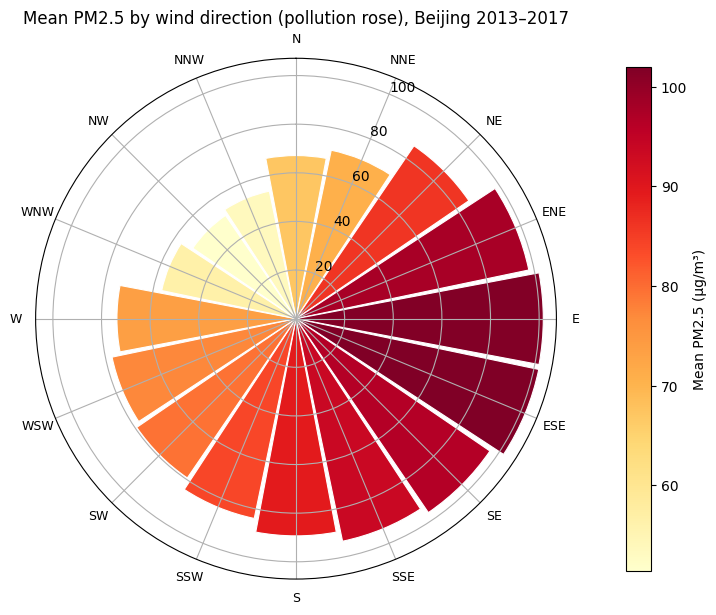

In [3]:
order = ["N","NNE","NE","ENE","E","ESE","SE","SSE","S","SSW","SW","WSW","W","WNW","NW","NNW"]
rose = df.groupby("wd")["PM2.5"].mean().reindex(order)
print("dirtiest direction:", rose.idxmax(), f"({rose.max():.0f} µg/m³)")
print("cleanest direction:", rose.idxmin(), f"({rose.min():.0f} µg/m³)")

angles = np.deg2rad(np.arange(0, 360, 22.5))
width = np.deg2rad(22.5)
norm = Normalize(rose.min(), rose.max())
cmap = plt.cm.YlOrRd

fig = plt.figure(figsize=(7.5, 7.5))
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.bar(angles, rose.values, width=width * 0.95, color=cmap(norm(rose.values)),
       edgecolor="white", linewidth=0.8)
ax.set_xticks(angles)
ax.set_xticklabels(order, fontsize=9)
ax.set_title("Mean PM2.5 by wind direction (pollution rose), Beijing 2013–2017", pad=25)
sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label("Mean PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()

The asymmetry is stark. Air arriving from the **east and southeast (E, ESE, ENE) carries ~100 µg/m³** on average — these winds sweep in from the industrial plain and the Bohai-rim cities. Air from the **northwest (NW, WNW, NNW) is roughly half as dirty (~50 µg/m³)**, descending clean and dry off the mountains.

This is a second, independent way weather sets PM2.5: a year with more southeasterly flow will look worse, a year with more northwesterly flushing will look better, regardless of what local emissions are doing. Together, Sections 1 and 2 show that PM2.5 is *strongly* weather-driven — so the trend in Part 2 cannot be read as an emissions signal until the weather is controlled.

## 3. Spatial variation — urban core vs. background stations

The twelve stations are not interchangeable. To see the spatial structure, we split them into two contrasting groups and compare their PM2.5 over time:

- **Urban core:** Dongsi, Tiantan, Wanshouxigong, Guanyuan — central, traffic- and population-dense sites.
- **Background:** Dingling, Huairou, Changping — northern, suburban/exurban sites away from the densest emissions.

If the citywide decline in Part 2 were an artifact of a few stations, the two groups would behave very differently. We plot each group's monthly mean PM2.5 (faint) with a 12-month centered rolling mean (bold) overlaid, matching the smoothing convention from Part 2.

Annual mean PM2.5 (µg/m³):
grp   Background  Urban
year                   
2014        76.9   87.9
2015        68.3   84.3
2016        60.9   77.4
  Urban: 2014→2016 change = -11.9%
  Background: 2014→2016 change = -20.9%
urban − background gap by year:
year
2014    10.9
2015    16.0
2016    16.6


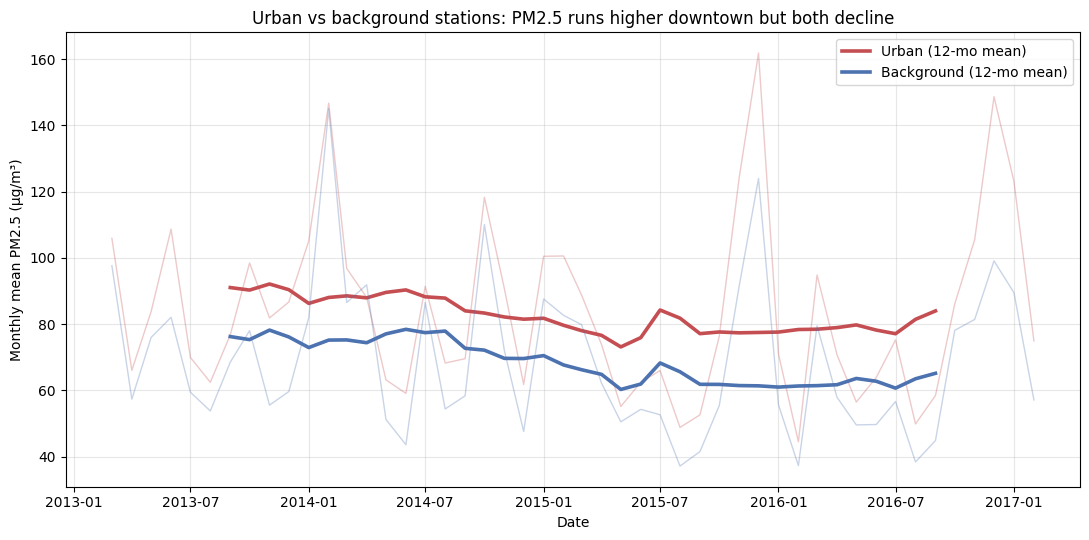

In [4]:
urban = ["Dongsi", "Tiantan", "Wanshouxigong", "Guanyuan"]
background = ["Dingling", "Huairou", "Changping"]

grp = pd.Series(pd.NA, index=df.index, dtype="object")
grp[df["station"].isin(urban)] = "Urban"
grp[df["station"].isin(background)] = "Background"
df["grp"] = grp
sub = df[df["grp"].isin(["Urban", "Background"])]

# Annual means for the three complete years, and the persistent urban–background gap
ann = (sub[sub["year"].isin([2014, 2015, 2016])]
       .groupby(["grp", "year"])["PM2.5"].mean().unstack(0))
print("Annual mean PM2.5 (µg/m³):")
print(ann.round(1).to_string())
for name in ["Urban", "Background"]:
    chg = (ann.loc[2016, name] - ann.loc[2014, name]) / ann.loc[2014, name] * 100
    print(f"  {name}: 2014→2016 change = {chg:+.1f}%")
print("urban − background gap by year:")
print((ann["Urban"] - ann["Background"]).round(1).to_string())

monthly = sub.groupby(["grp", pd.Grouper(freq="MS")])["PM2.5"].mean().unstack(0)
rolling = monthly.rolling(12, center=True).mean()
colors = {"Urban": "#c44e52", "Background": "#4c72b0"}

fig, ax = plt.subplots(figsize=(11, 5.5))
for name in ["Urban", "Background"]:
    ax.plot(monthly.index, monthly[name], color=colors[name], alpha=0.30, lw=1)
    ax.plot(rolling.index, rolling[name], color=colors[name], lw=2.6,
            label=f"{name} (12-mo mean)")
ax.set_xlabel("Date")
ax.set_ylabel("Monthly mean PM2.5 (µg/m³)")
ax.set_title("Urban vs background stations: PM2.5 runs higher downtown but both decline")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Two things stand out. First, the **urban core is persistently dirtier** — its 12-month mean sits roughly 11–17 µg/m³ above the background sites throughout the record, and the gap does not close. Second, and more importantly for the policy question, **both groups fall together**: the decline is a citywide phenomenon, not an artifact of a handful of stations.

Interestingly, in relative terms the *background* sites improved more (about −21% vs. −12% at the urban core over 2014→2016). Because background sites are less dominated by local traffic, they respond more visibly to regional-scale changes — but note that this raw comparison still ignores weather, which the final section now addresses head-on.

## 4. Does the PM2.5 decline survive the weather? Stagnant-day test

This is the central test of the notebook. Sections 1–2 showed PM2.5 is strongly controlled by wind. So we ask: **on days when the weather offers no help — calm, stagnant days when pollution cannot disperse — did PM2.5 still fall from 2014 to 2016?** If the decline is driven by reduced emissions, it should show up even on stagnant days. If it is mostly the weather cooperating, it will vanish once we hold conditions fixed.

Method: aggregate to a daily citywide series (mean PM2.5 and mean wind speed per day), then define **stagnant days** as the calmest 25% of all days (daily mean wind ≤ the 25th percentile, a *fixed* threshold so 2014 and 2016 are judged on the same yardstick). We compare the 2014→2016 change on all days, on windy days (top 25%), and on stagnant days.

stagnant-day threshold = 1.24 m/s (25th pct of daily mean wind)

Mean daily wind speed by year (m/s):
year
2014    1.64
2015    1.77
2016    1.84
Number of stagnant days by year:
year
2014    98
2015    78
2016    72

2014→2016 PM2.5 change:
  All days                  :  86.0 →  71.8 µg/m³  (-16.5%)
  Windy days (top 25%)      :  40.0 →  37.1 µg/m³  (-7.4%)
  Stagnant days (bottom 25%): 128.1 → 138.1 µg/m³  (+7.8%)


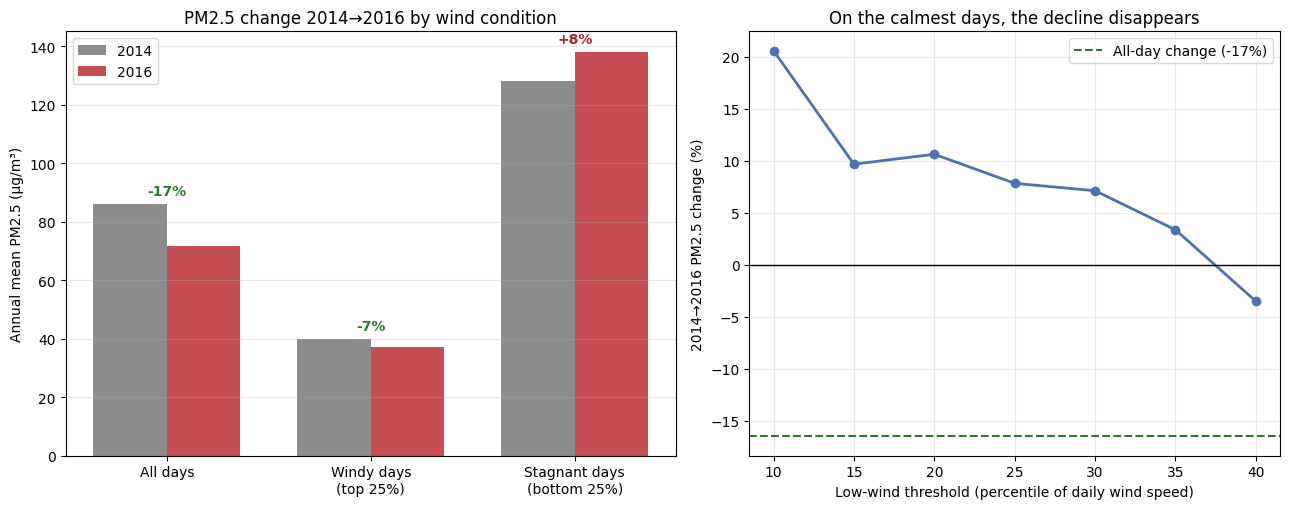

In [5]:
daily = df.resample("D").agg(pm=("PM2.5", "mean"), ws=("WSPM", "mean"))
daily["year"] = daily.index.year

low_thr = daily["ws"].quantile(0.25)      # stagnant: calmest 25% of days
high_thr = daily["ws"].quantile(0.75)     # windy: breeziest 25% of days
print(f"stagnant-day threshold = {low_thr:.2f} m/s (25th pct of daily mean wind)")

# Meteorology itself shifted between the years — this is the confound, quantified
print("\nMean daily wind speed by year (m/s):")
print(daily.groupby("year")["ws"].mean().loc[2014:2016].round(2).to_string())
print("Number of stagnant days by year:")
stag = daily["ws"] <= low_thr
print(daily.assign(stag=stag).groupby("year")["stag"].sum().loc[2014:2016].to_string())

def pct(a, b):
    return (b - a) / a * 100

conds = {
    "All days": daily["pm"].notna(),
    "Windy days\n(top 25%)": daily["ws"] >= high_thr,
    "Stagnant days\n(bottom 25%)": daily["ws"] <= low_thr,
}
vals = {yr: [daily.loc[(daily["year"] == yr) & m, "pm"].mean() for m in conds.values()]
        for yr in (2014, 2016)}
print("\n2014→2016 PM2.5 change:")
for i, name in enumerate(conds):
    label = name.replace(chr(10), " ")
    print(f"  {label:<26}: {vals[2014][i]:5.1f} → {vals[2016][i]:5.1f} µg/m³  ({pct(vals[2014][i], vals[2016][i]):+.1f}%)")

# Sensitivity: how the change depends on where we draw the "low-wind" line
pcts = np.arange(0.10, 0.45, 0.05)
sens = []
for q in pcts:
    t = daily["ws"].quantile(q)
    s = daily[daily["ws"] <= t]
    a = s.loc[s["year"] == 2014, "pm"].mean()
    b = s.loc[s["year"] == 2016, "pm"].mean()
    sens.append(pct(a, b))
allday = pct(vals[2014][0], vals[2016][0])

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5.2),
                               gridspec_kw={"width_ratios": [1.15, 1]})
x = np.arange(len(conds)); w = 0.36
axA.bar(x - w/2, vals[2014], w, label="2014", color="#8c8c8c")
axA.bar(x + w/2, vals[2016], w, label="2016", color="#c44e52")
for i in range(len(conds)):
    chg = pct(vals[2014][i], vals[2016][i])
    axA.text(x[i], max(vals[2014][i], vals[2016][i]) + 3, f"{chg:+.0f}%",
             ha="center", fontweight="bold", fontsize=10,
             color=("#2a7a2a" if chg < 0 else "#b02020"))
axA.set_xticks(x); axA.set_xticklabels(conds.keys())
axA.set_ylabel("Annual mean PM2.5 (µg/m³)")
axA.set_title("PM2.5 change 2014→2016 by wind condition")
axA.legend(); axA.grid(alpha=0.3, axis="y")

axB.plot(pcts * 100, sens, marker="o", color="#4c72b0", lw=2)
axB.axhline(0, color="k", lw=1)
axB.axhline(allday, color="#2a7a2a", ls="--", lw=1.5, label=f"All-day change ({allday:.0f}%)")
axB.set_xlabel("Low-wind threshold (percentile of daily wind speed)")
axB.set_ylabel("2014→2016 PM2.5 change (%)")
axB.set_title("On the calmest days, the decline disappears")
axB.grid(alpha=0.3); axB.legend()
plt.tight_layout()
plt.show()

The result is the most important — and most cautionary — finding of Part 3.

- On **all days**, PM2.5 fell about **−17%**, matching Part 2.
- On **windy days**, the decline is much smaller (about −7%).
- On **stagnant days, the decline vanishes** — PM2.5 was essentially flat to *higher* in 2016 (about +8% at the 25% threshold).

The left panel also shows *why*: the weather itself shifted in Beijing's favour. Mean daily wind speed rose from **1.64 m/s (2014) to 1.84 m/s (2016)**, and the number of stagnant days fell from **98 to 72**. So a meaningful part of the headline −17% is not cleaner emissions but simply **fewer bad-weather days** in 2016. The right panel confirms this is not an artifact of where we draw the line: across every low-wind cutoff from the calmest 10% to 30% of days, the 2014→2016 change stays at or above zero — nowhere near the all-day −17%. It only turns negative once we widen the definition enough to let windier days back in.

**Caveats.** Stagnant-day means rest on ~70–100 days per year and are dominated by a few extreme haze episodes, so the exact magnitude (and the sign at the very tightest thresholds) is noisy. The robust, threshold-insensitive claim is directional: *the PM2.5 improvement is concentrated on windy days and does not hold on the calmest days.*

## Conclusion

Part 3 set out to test whether Beijing's 2014→2016 PM2.5 decline survives after accounting for the weather, and to map its spatial structure. The evidence:

1. **PM2.5 is strongly weather-controlled.** It drops ~3.5× from calm to windy hours (Section 1), and air from the industrial southeast carries roughly double the PM2.5 of clean northwesterly flow (Section 2). Weather is not a minor nuisance here — it is a first-order driver.
2. **The decline is citywide, not local.** Urban-core stations run persistently ~11–17 µg/m³ dirtier than background sites, but both groups fall together (Section 3), so the trend is a real regional signal rather than a few stations.
3. **But the decline is substantially weather-aided.** 2016 was genuinely windier than 2014 (fewer stagnant days), and once we restrict to stagnant days — holding the dispersion conditions adverse and fixed — the 2014→2016 PM2.5 improvement disappears (Section 4).

This refines the project's hypothesis rather than overturning it. PM2.5 *did* improve, but the raw −17% overstates the emissions-driven part: a chunk of it is favourable meteorology in 2016. This stands in clear contrast to SO₂, which Part 2 found falling by more than half — a decline far too large to be explained by wind. **The overall picture across the three notebooks is consistent: coal-linked SO₂ shows the clean, unambiguous policy signal, while PM2.5's more modest improvement is real but genuinely entangled with — and flattered by — the weather, exactly as hypothesized.**